In [1]:
from importlib.metadata import version
print("langchain version: ", version("langchain"))
print("langgraph version: ", version("langgraph"))
print("langchain-openai version: ", version("langchain-openai"))
print("langchain-core version: ", version("langchain-core"))
print("langchain_community version: ", version("langchain_community"))
print("langchain_mcp_adapters version: ", version("langchain_mcp_adapters"))
print("tavily-python version: ", version("tavily-python"))

langchain version:  1.4.2
langgraph version:  1.2.12
langchain-openai version:  1.6.6
langchain-core version:  1.6.5
langchain_community version:  0.4.2
langchain_mcp_adapters version:  0.3.2
tavily-python version:  0.8.0


In [2]:
import os
from dotenv import load_dotenv
import openai
load_dotenv()

True

2026-10-06 22:14:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'draft' with handle 'deepseek-flash' (timeout=600)
2026-10-06 22:14:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_summarizer' with handle 'deepseek-flash' (timeout=600)
2026-10-06 22:14:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'writer' with handle 'deepseek-flash' (timeout=600)
2026-10-06 22:14:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_main' with handle 'deepseek-flash' (timeout=600)
2026-10-06 22:14:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_compressor' with handle 'deepseek-flash' (timeout=600)
2026-10-06 22:14:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'red_team' with handle 'deepseek-flash' (timeout=600)
2026-10-06 22:14:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'evaluator'

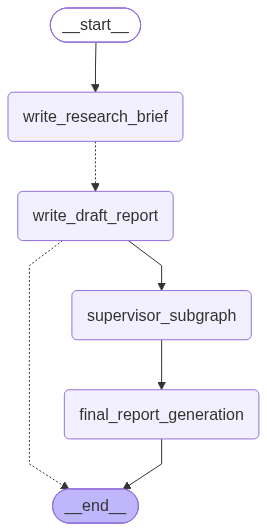

In [3]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research.agent_builder import deep_researcher_builder
import warnings

warnings.filterwarnings("ignore")
checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# take 10 ~ 20 minutes to finish the task.
from langchain_core.messages import HumanMessage
from deep_research import iteration_config
thread = {"configurable": {"thread_id": "1"}, "recursion_limit": iteration_config.GRAPH_RECURSION_LIMIT}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="我是个 AI 产品经理，正在考虑给产品增加个性化记忆功能。想系统了解一下现在 Agent 里的 Memory 模块都在往哪些方向发展，包括短期和长期记忆是怎么做的、各种技术路线的差异和取舍。你帮我写个调研报告，从工程落地和未来演进的角度分析一下 哪些方向更值得投入")]}, config=thread)

2026-10-06 22:14:49 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=0, messages=1)
2026-10-06 22:14:53 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-10-06 22:14:53 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-10-06 22:14:53 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=1, messages=3)
2026-10-06 22:14:58 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=3
2026-10-06 22:14:58 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=0 conduct=3 refine=0
2026-10-06 22:15:00 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=4
2026-10-06 22:15:00 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-10-06 22:15:00 [INFO] 

In [5]:
from rich.console import Console
from rich.markdown import Markdown

# 创建控制台对象
console = Console()
console.print(Markdown(result["final_report"]))

Agent 个性化记忆（Memory）模块系统性调研报告                                    

决策摘要                                                                                                           

核心结论：不存在"最优"的记忆路线，只有"最匹配场景"的路线。记忆应作为"可被检索、可被治理的认知资产"来架构，而非简单 
的聊天记录。产品决策的核心逻辑是——从需求的结构性、变更频率、合规强度、一致性要求四个维度出发，走"向量起步→结构化增 
强→图/分层攻坚"的渐进式演进路径。                                                                                  

能力栈（模块化，非一次性选型）：检索层（向量 RAG 起步）+ 结构化画像层（用户偏好/事实）+                            
治理层（写入门控/TTL/遗忘）+ 可选图/分层记忆层。这一能力栈对应渐进路线，可避免一步到位的过度工程。                 

条件化选型分支（仅在满足对应条件时才落到具体方案）：                                                               

                                                                                                                   
 条件                        建议路径                                          关键依据                            
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 预算受限/小团队             托管记忆层 + 声明式程序记忆（CLAUDE.md 类文件）…  上线最快、成本最低                  
                             TTL 兜底                                                                              
 合规敏感（医疗/金融/法律）  结构化记忆 + 存储层多租户隔离 + 双时间建模 +      GDPR 要求原子级删除                 
                             可删除可审计                                                                          
 延迟敏感（消费级/语音）     分层架构（先向量）+ 检索层缓存 +                  Zep 检索无 LLM 调用、P95 300ms [5]  
                             避免每次分页调用 LLM                                                                  
 企业多租户                  每租户独立索引 + 层级命名空间 + 混合向量-图       共享索引是最常见跨租户泄露来源 [34] 
 长期运行自主 Agent          分层记忆 + 程序性记忆 + 写入/遗忘治理             历史记录庞大需自主管理              
                                                                                                                   

六个值得投入的方向（区分"方向重要性"与"立即投入优先级"）：                                                         

                                                                                                                   
 方向                            时间窗            证据强度          核心判断依据                                  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 分层记忆架构                    短期              强                纯向量在多跳/时序推理触及瓶颈 [14]            
 生命周期治理（写入/更新/遗忘）  短期              强                写入路径决定记忆质量上限 [24]                 
 记忆质量可评测体系              短期              中                厂商自测偏差严重，需自建真实数据评测集 [8]    
 安全与合规基础设施              短期（合规刚需）  中                记忆投毒攻击成功率高；GDPR 要求原子级删除     
                                                                     [34]                                          
 程序性记忆管理                  中期              弱（早期研究）    杠杆最高但最不成熟；托管平台尚未产品化 [24]   
 统一记忆协议与可移植性          中长期            弱（预印本阶段）  记忆格式是锁定来源；标准化尝试刚起步 [32]     
                                                                                                                   

成本量级：托管方案月费从免费到数百美元；自建基础设施成本更高；写入路径是隐藏账单（每个框架都触发 LLM               
调用来提取/协调记忆）[8]。                                                                                         

数据可信度提示：当前基准测试存在严重的厂商自测偏差；同一系统换评判模型分数可变动两位数，跨厂商比较通常无意义。唯一 
值得信任的是在自身产品场景真实数据上复现的数字 [8]。                                                               

一、短期记忆与长期记忆的实现方式                                                                                   

1.1 短期记忆（工作记忆/对话上下文）                                                                                

1.1.1 核心约束与阈值                                                                                               

LLM 本质上是无状态推理引擎，每次请求独立处理，不会保留对话状态，除非将先前上下文包含在提示中                       
[24]。短期记忆因此在模型外部实现——应用层存储状态，并在每次模型调用前重建上下文。CoALA 论文（Sumers et al.,         
2023）将工作记忆定义为推理期间持有目标与观察的活动状态 [2]。                                                       

Token 增长是核心约束。生产实践观察表明 [24]：低于 4,000 token 的会话通常无需主动管理；8,000–16,000 token           
时需监控；接近上下文窗口 60%–70% 时应激活管理策略。这些阈值基于生产观

In [7]:
from datetime import date
path = f"./output_report_{date.today().strftime("%Y-%m-%d")}.md"
with open(path, "w",  encoding="utf-8") as fd:
    fd.write(result["final_report"])
print(f"调研报告已保存在{path}.")

调研报告已保存在./output_report_2026-10-06.md.


In [8]:
print(result["final_report"])

# Agent 个性化记忆（Memory）模块系统性调研报告

## 决策摘要

**核心结论**：不存在"最优"的记忆路线，只有"最匹配场景"的路线。记忆应作为"可被检索、可被治理的认知资产"来架构，而非简单的聊天记录。产品决策的核心逻辑是——从**需求的结构性、变更频率、合规强度、一致性要求**四个维度出发，走"向量起步→结构化增强→图/分层攻坚"的渐进式演进路径。

**能力栈（模块化，非一次性选型）**：检索层（向量 RAG 起步）+ 结构化画像层（用户偏好/事实）+ 治理层（写入门控/TTL/遗忘）+ 可选图/分层记忆层。这一能力栈对应渐进路线，可避免一步到位的过度工程。

**条件化选型分支**（仅在满足对应条件时才落到具体方案）：

| 条件 | 建议路径 | 关键依据 |
|---|---|---|
| 预算受限/小团队 | 托管记忆层 + 声明式程序记忆（CLAUDE.md 类文件）+ TTL 兜底 | 上线最快、成本最低 |
| 合规敏感（医疗/金融/法律） | 结构化记忆 + 存储层多租户隔离 + 双时间建模 + 可删除可审计 | GDPR 要求原子级删除 |
| 延迟敏感（消费级/语音） | 分层架构（先向量）+ 检索层缓存 + 避免每次分页调用 LLM | Zep 检索无 LLM 调用、P95 300ms [5] |
| 企业多租户 | 每租户独立索引 + 层级命名空间 + 混合向量-图 | 共享索引是最常见跨租户泄露来源 [34] |
| 长期运行自主 Agent | 分层记忆 + 程序性记忆 + 写入/遗忘治理 | 历史记录庞大需自主管理 |

**六个值得投入的方向**（区分"方向重要性"与"立即投入优先级"）：

| 方向 | 时间窗 | 证据强度 | 核心判断依据 |
|---|---|---|---|
| 分层记忆架构 | 短期 | 强 | 纯向量在多跳/时序推理触及瓶颈 [14] |
| 生命周期治理（写入/更新/遗忘） | 短期 | 强 | 写入路径决定记忆质量上限 [24] |
| 记忆质量可评测体系 | 短期 | 中 | 厂商自测偏差严重，需自建真实数据评测集 [8] |
| 安全与合规基础设施 | 短期（合规刚需） | 中 | 记忆投毒攻击成功率高；GDPR 要求原子级删除 [34] |
| 程序性记忆管理 | 中期 